In [1]:
import numpy as np
import scipy as scipy
import scipy.special
import scipy.stats as stats
import matplotlib.pyplot as plt
from matplotlib import colors
import time
import uncertainties as error
import pandas as pd
np.random.seed(12345)

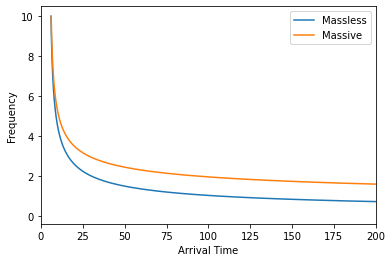

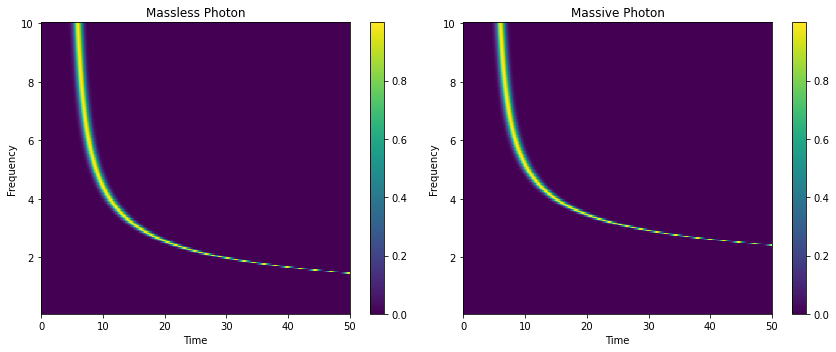

In [20]:
#Making a demonstration plot showing how the dispersion is different in the two regiemes
frequency = np.linspace(0.1, 10, 200)
time = np.linspace(0, 50, 500)

Time, Nu = np.meshgrid(time, frequency) #meshgridding

#tunable parameters
D = 100 #dispersion constant
t0 = 5 #inital flash time
sigma = 0.5 #flash width
m = 1.0 #mass of photon
K = 1000 #just a scaling constant to amplify the effect

#classical photon dispersion
t_arrival_1 = t0 + D / (frequency**2)
#massive photon dispersion
t_arrival_2 = t0 + D / (frequency**2) + K * m**2 / (frequency**4)

#This shows the actual relationship
plt.plot(t_arrival_1, frequency, label='Massless')
plt.plot(t_arrival_2, frequency, label='Massive')
plt.xlim(0, 200)
plt.ylabel('Frequency')
plt.xlabel('Arrival Time')
plt.legend()
plt.show()


#we can assume a gaissian profile for the initial flash
t_arrival_1 = t_arrival_1[:, None] #need to reshape to be used in the meshgrid
t_arrival_2 = t_arrival_2[:, None]
intensity_1 = np.exp(-((Time - t_arrival_1)**2) / (2 * sigma**2))
intensity_2 = np.exp(-((Time - t_arrival_2)**2) / (2 * sigma**2))

#and plot 2 images because idk how to stack these on top of each other
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

im1 = axs[0].pcolormesh(Time, Nu, intensity_1, shading='auto')
axs[0].set_title('Massless Photon')
axs[0].set_xlabel('Time')
axs[0].set_ylabel('Frequency')
plt.colorbar(im1, ax=axs[0])

im2 = axs[1].pcolormesh(Time, Nu, intensity_2, shading='auto')
axs[1].set_title('Massive Photon')
axs[1].set_xlabel('Time')
axs[1].set_ylabel('Frequency')
plt.colorbar(im2, ax=axs[1])

plt.tight_layout()
plt.show()




In [22]:
#Let's do the MC
#We will look at Eq. 9 and 10. We see that the paper assumes all observed time delay is from the massive photon
#At least for the upper bound. This works but we want to instead add some systemic time delay from outside sources
#We will then find the PDF using MC and find the 90% confidence interval(or something similar) to report our value

#Let's start with priors
#We need a few:
    #Photon Mass: mass
    #Strength of mass dependent dispersion: DM (see comments below why this is DM and not arbitrary constant)
    #Pulsar Timing Variation: sigma_PTV
    #A general catchall for systematics: systematic
def LogPrior(theta):
    mass, DM, sigma_PTV, systematic = theta
    #Let's set some sanity bounds
    if mass < 0: #No negative mass photons
        return(-np.inf)
    if sigma_PTV < 0: #This is a standard deviation so should always be positive
        return(-np.inf)
    m_min, m_max = 1e-90, 1e-30 #setting these just so it doesn't search outside of a reasonable range
    if not (m_min < mass < m_max):
        return(-np.inf)
    
    #Let's build our prior. Since we are in log space we just add all the components
    #Photon mass will be a scale parameter, so we should use a Jefferies Prior. This is just -log(mass)
    temp = -np.log(mass)
    
    #Now we handle A
    #I think because it's related to the classical dispersion measurement it's the DM measurements from the pulsars
    #The value for this is actually somewhat calculable. 
    #deltat = DM * elementary charge**2/(2*np.pi*m_electron*c) * (frequency**−2)
    #deltat = DM * constant * frequency**-2
    #We handle the frequency part within the deltat later, so really A is some constant multiplied by DM
    #https://www.aanda.org/articles/aa/pdf/2024/12/aa50740-24.pdf this paper defines this constant as 4.15E3
    #anyway this lets us do DM as the prior and not A. Let's do a gaussian prior with some central value + width
    temp += -0.5*((DM - DM_0)/sigma_DM)**2
    #NOTE DM_0 and sigma_DM should be taken from the Table 2. DM is some random value, DM_0 and sigma_DM are measurements
    
    #PVT is some scale parameter again
    temp += -np.log(sigma_PTV)
    
    #and our systematic parameter is some gaussian value
    systematic_scale = 10.0  # idk what this should be really. Some sigma_systematic
    #Really iy should be a sigma from some measurements of time delay...
    temp += -0.5 * (systematic / systematic_scale)**2
    
    return(temp)

In [23]:
#Lets now handle likelyhood
#First we should make a model function again for the dispersion. Kinda done above already for those example plots
def model(theta, frequency):
    mass, DM, sigma_PTV, systematic = theta
    K_DM = 4.15E3 #Classical Dispersion Constant https://www.aanda.org/articles/aa/pdf/2024/12/aa50740-24.pdf\\
    K_mass = 1 #Not sure what this one should be
#     deltat = t0 + (K_DM * DM / (frequency**2)) + K * mass**2 / (frequency**4)
    Classical = K_DM * DM * frequency**(-2) #Classical Dispersion
    Massive = K_mass * mass**2 * frequency**(-4) #Massive Photon Dispersion
    return(Classical + Massive + systematic) #delay time deltat_observed = deltat_classical + deltat_mass + deltat_systematic

def LogLikelihood(theta, frequency, deltat, sigmat):
    mass, DM, sigma_PTV, systematic = theta
    residual = deltat - model(theta, frequency) #subtract observed deltat from model deltat
    sigma_eff = np.sqrt(sigmat**2 + sigma_PTV**2) #add sigma terms in quad
    #Now we do a log-likelyhood
    temp = -0.5 * np.sum((residual**2 / sigma_eff**2)+ np.log(2 * np.pi * sigma_eff**2))
    return(temp)

In [26]:
def LogPosterior(theta, frequency, dt_obs, sigma_obs):
    lnPrior = LogPrior(theta)
    if not np.isfinite(lnPrior): #just a sanity check
        return(-np.inf) #no posterior is prior is not valid
    return(lnPrior + LogLikelihood(theta, frequency, dt_obs, sigma_obs))

In [81]:
#Let's start doing an MC
#Lets use some Source 1 Data
frequency = np.linspace(100, 10000, 200)  #MHz for units in K_DM
DM_0 = 38.78
sigma_DM = 0.158
deltat_observed = 10 #uhh gotta find where these numbers are
sigma_t_observed = 0.1 #this one too

#Setup our random samples
N = 4000
samples = []
logw = []

def ThetaGenerator(): #this just makes some theta values to guess
    mass = np.exp(np.random.uniform(np.log(1e-90), np.log(1e-30)))
    DM = np.random.normal(DM_0, sigma_DM)
    sigma_PTV = np.exp(np.random.uniform(np.log(1e-6), np.log(1e2)))
    systematic = np.random.normal(0, 10.0)
    return(mass, DM, sigma_PTV, systematic)

for i in range(N):
    theta = ThetaGenerator() #Generate some thetas (sample parameters)
    lp = LogPrior(theta) #Find the prior for theta
    ll = LogLikelihood(theta, frequency, deltat_observed, sigma_t_observed) #and the likelyhood for theta
    samples.append(theta) #save the thetas
    logw.append(ll+lp) #save the result from bayes
#     print('LogPrior:', lp, 'LogLikelihood:', ll)

logw = np.array(logw) #these weights are what we'll do the pdf with
logw -= np.max(logw) #we need to normalize and get them out of log space
w = np.exp(logw)
w /= np.sum(w)

samples = np.array(samples) #convert to an array
mass_samples = samples[:, 0] #Just get the mass values out

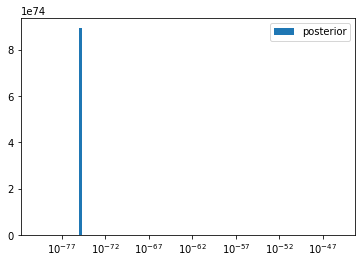

In [86]:
plt.hist(mass_samples,
         bins=np.logspace(-80, -45, 100),
         weights=w,
         density=True,
         label='posterior')

plt.xscale('log')
plt.legend()
plt.show()

#uh oh this seems a little too small
#Was expecting something with a shape extending out past the main paper's result
#Though I guess actually smaller is ok provided we can nail down some of these numbers
#since smaller just means the like systematic terms matter more and stuff so the photon mass is less impactful
#in terms of the delay time that is

#I mean also K_mass, deltat_observed, and sigma_t_observed I don't have quite down yet so this isn't completeanyway